# 03 — Modélisation — Axe 2 : Stroke Severity (Version 3 — Optimisation avancée)

**Projet :** Stroke Prediction AI — IST Dataset  
**Notebook :** 03 — Modélisation V3  
**Version :** V3 — RandomizedSearchCV + Threshold Adjustment + Calibration + SHAP + Analyse erreurs  
**Dataset :** `IST_corrected.csv` — 19 435 patients · 112 variables  
**Auteur :** ML_Project 2025-2026

---

## Objectif de ce notebook

Ce notebook est la **Version 3** — optimisation avancée du pipeline V2.  
Il répond à la question : **Comment pousser les performances au maximum et rendre le modèle explicable ?**

### Ce qui change par rapport à V2
| Étape | V2 | V3 |
|-------|----|----|
| Optimisation | GridSearchCV | **RandomizedSearchCV** (plus efficace, espace large) |
| Seuil décision | 0.5 par défaut | **Threshold adjustment** (optimisé pour recall sévère) |
| Probabilités | Brutes | **Calibration** (Platt scaling) |
| Explicabilité | Feature importance | **SHAP values** (summary + waterfall + force plot) |
| Erreurs | Matrice confusion | **Analyse qualitative** des profils mal classés |
| Validation | Test set unique | **CV stabilité** (moyenne ± écart-type sur 5 folds) |
| Sauvegarde | Modèle seul | **Pipeline complet** + fonction prédiction patient unique |

### Modèles comparés (identiques à V2)
- LogisticRegression · DecisionTree · RandomForest · GradientBoosting · XGBoost

---

## Plan du notebook
1. Configuration et imports  
2. Chargement des artefacts V2  
3. Rappel : modèles baseline V2  
4. **RandomizedSearchCV** sur tous les modèles  
5. Comparaison GridSearch V2 vs RandomizedSearch V3  
6. **Threshold adjustment** (seuil de décision)  
7. **Calibration des probabilités**  
8. **SHAP Values** — explicabilité  
9. **Analyse qualitative des erreurs**  
10. Validation croisée de stabilité  
11. Sauvegarde production-ready  
12. Conclusion V3

---
## Section 1 — Configuration et imports

In [20]:
# ============================================================
# 1.1 — Imports standards + nouveaux imports V3
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os, sys, json, joblib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# sklearn — modèles
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import StandardScaler, OneHotEncoder, label_binarize

# sklearn — validation et optimisation
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV      # V3 : les deux pour comparaison
)

# sklearn — métriques
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

# sklearn — calibration (V3)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# scipy — distributions pour RandomizedSearch (V3)
from scipy.stats import randint, uniform

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print(" XGBoost disponible")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost non disponible — pip install xgboost")

# SHAP (V3)
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP disponible")
except ImportError:
    SHAP_AVAILABLE = False
    print(" SHAP non disponible — pip install shap")

# ── Configuration globale ─────────────────────────────────────
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})

# ── Constantes (identiques V2) ────────────────────────────────
LABEL_ORDER   = ["leger", "modere", "severe"]
LABEL_MAP     = {"leger": 0, "modere": 1, "severe": 2}
LABEL_MAP_INV = {0: "léger", 1: "modéré", 2: "sévère"}
COLORS_CLASS  = {"leger": "#2ecc71", "modere": "#f39c12", "severe": "#e74c3c"}
COLORS_MODEL  = {
    "LogisticRegression": "#3498db",
    "DecisionTree"      : "#9b59b6",
    "RandomForest"      : "#2ecc71",
    "GradientBoosting"  : "#e67e22",
    "XGBoost"           : "#e74c3c",
}

print(" Tous les imports V3 chargés")

 XGBoost disponible
SHAP disponible
 Tous les imports V3 chargés


In [21]:
# ============================================================
# 1.2 — Montage Drive + configuration (identique V2)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT  = Path("/content/drive/MyDrive/ML_Project")
SRC_PATH      = PROJECT_ROOT / "src"

# Dossiers artefacts
ARTIFACTS_V2  = PROJECT_ROOT / "artifacts" / "axe2" / "v2"
ARTIFACTS_V3  = PROJECT_ROOT / "artifacts" / "axe2" / "v3"
MODELS_V3_DIR = ARTIFACTS_V3 / "models"

# Création des dossiers V3 si besoin
ARTIFACTS_V3.mkdir(parents=True, exist_ok=True)
MODELS_V3_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import importlib, config
importlib.reload(config)
from config import DATA_PATH, RANDOM_STATE

print(f"ARTIFACTS_V2  : {ARTIFACTS_V2}")
print(f"ARTIFACTS_V3  : {ARTIFACTS_V3}")
print(f"MODELS_V3_DIR : {MODELS_V3_DIR}")
print(f"RANDOM_STATE  : {RANDOM_STATE}")
print("Configuration V3 chargée")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ARTIFACTS_V2  : /content/drive/MyDrive/ML_Project/artifacts/axe2/v2
ARTIFACTS_V3  : /content/drive/MyDrive/ML_Project/artifacts/axe2/v3
MODELS_V3_DIR : /content/drive/MyDrive/ML_Project/artifacts/axe2/v3/models
RANDOM_STATE  : 42
Configuration V3 chargée


---
## Section 2 — Chargement des artefacts V2

Les artefacts V2 sont réutilisés directement.  
Aucun re-preprocessing n'est nécessaire : on repart des mêmes données que V2.

In [22]:
# ============================================================
# 2.1 — Chargement des artefacts V2
# ============================================================
# Produits par le notebook 02_Preprocessing_IST_Axe2_Severity_V2 :
#   X_train_smote.csv       : train après SMOTE (index=False à la sauvegarde)
#   X_test_preprocessed.csv : test preprocessé  (index=False)
#   y_train_smote.csv       : labels train       (index=False)
#   y_test.csv              : labels test        (index=True  → index_col=0)
#   preprocessor_v2.pkl     : ColumnTransformer fitté sur X_train

X_train = pd.read_csv(ARTIFACTS_V2 / "X_train_smote.csv")
X_test  = pd.read_csv(ARTIFACTS_V2 / "X_test_preprocessed.csv")
y_train = pd.read_csv(ARTIFACTS_V2 / "y_train_smote.csv").squeeze()
y_test  = pd.read_csv(ARTIFACTS_V2 / "y_test.csv", index_col=0).squeeze()

# Conversion en entiers (attendu par sklearn)
y_train = y_train.astype(int)
y_test  = y_test.astype(int)

print("Artefacts V2 chargés :")
print(f"  X_train (après SMOTE) : {X_train.shape}")
print(f"  X_test                : {X_test.shape}")
print(f"  y_train               : {y_train.shape}")
print(f"  y_test                : {y_test.shape}")
print()
print("Distribution y_train (après SMOTE) :")
ct = Counter(y_train)
for k in sorted(ct):
    print(f"  {LABEL_MAP_INV[k]:8s} ({k}) : {ct[k]:5d} ({ct[k]/len(y_train)*100:.1f}%)")
print()
print("Distribution y_test (sans SMOTE — évaluation honnête) :")
ct_test = Counter(y_test)
for k in sorted(ct_test):
    print(f"  {LABEL_MAP_INV[k]:8s} ({k}) : {ct_test[k]:5d} ({ct_test[k]/len(y_test)*100:.1f}%)")

Artefacts V2 chargés :
  X_train (après SMOTE) : (21983, 41)
  X_test                : (3884, 41)
  y_train               : (21983,)
  y_test                : (3884,)

Distribution y_train (après SMOTE) :
  léger    (0) :  7753 (35.3%)
  modéré   (1) :  6477 (29.5%)
  sévère   (2) :  7753 (35.3%)

Distribution y_test (sans SMOTE — évaluation honnête) :
  léger    (0) :  1939 (49.9%)
  modéré   (1) :  1619 (41.7%)
  sévère   (2) :   326 (8.4%)


In [23]:
# ============================================================
# 2.2 — Construction du preprocesseur adapté à X_train V2
# ============================================================
# X_train_smote.csv est la sortie de preprocessor_v2 + SMOTE.
# Toutes ses colonnes sont numériques (OHE déjà appliqué en V2).
# → Un simple SimpleImputer + StandardScaler suffit comme pipeline interne
#   pour que RandomizedSearchCV re-fitte proprement sur chaque fold.
#
# On charge quand même preprocessor_v2.pkl pour référence / SHAP plus tard.

preprocessor_v2 = joblib.load(ARTIFACTS_V2 / "preprocessor_v2.pkl")
print("preprocessor_v2.pkl chargé (référence pour SHAP)")

# Preprocesseur léger adapté aux features transformées de X_train
# Toutes les colonnes de X_train sont numériques après V2
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocessor_v3 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

print(" preprocessor_v3 construit (adapté aux features de X_train)")
print(f"   Colonnes X_train : {X_train.shape[1]} (toutes numériques)")
print(f"   Pipeline : SimpleImputer(median) → StandardScaler")

preprocessor_v2.pkl chargé (référence pour SHAP)
 preprocessor_v3 construit (adapté aux features de X_train)
   Colonnes X_train : 41 (toutes numériques)
   Pipeline : SimpleImputer(median) → StandardScaler


In [24]:
# ============================================================
# 2.3 — Vérification et stratégie clone()
# ============================================================

from sklearn.base import clone

# Test : preprocessor_v3 peut transformer X_train sans erreur
_ = preprocessor_v3.fit_transform(X_train)
print("preprocessor_v3.fit_transform(X_train) OK")

_ = preprocessor_v3.transform(X_test)
print("preprocessor_v3.transform(X_test) OK")
print()
print("Stratégie dans la boucle RandomizedSearchCV :")
print("  Pipeline([(preprocessor_v3_clone), (model_clone)])")
print("  → clone() crée une copie fraîche (non fittée) à chaque itération")
print("  → sklearn re-fitte sur chaque fold → pas de data leakage")

preprocessor_v3.fit_transform(X_train) OK
preprocessor_v3.transform(X_test) OK

Stratégie dans la boucle RandomizedSearchCV :
  Pipeline([(preprocessor_v3_clone), (model_clone)])
  → clone() crée une copie fraîche (non fittée) à chaque itération
  → sklearn re-fitte sur chaque fold → pas de data leakage


---
## Section 3 — Définition des modèles (identiques à V2)

Les 5 modèles sont **exactement les mêmes** qu'en V2.  
Cela garantit une comparaison juste : seule la méthode d'optimisation change (Randomized vs Grid).

In [25]:
# ============================================================
# 3.1 — Modèles avec hyperparamètres de base optimisés
# ============================================================
# n_estimators réduits pour RF et GradientBoosting
# max_iter réduit pour LogisticRegression

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=500,                  # 1000 → 500
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="lbfgs",
        multi_class="multinomial"
    ),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,              # 200 → 100
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=50,               # 100 → 50
        learning_rate=0.1,
        max_depth=4,
        random_state=RANDOM_STATE,
        subsample=0.8                  # ajout : entraîne sur 80% des données → plus rapide
    ),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=100,              # 200 → 100
        learning_rate=0.1,
        max_depth=5,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        subsample=0.8,                 # entraîne sur 80% → plus rapide
        colsample_bytree=0.8           # 80% des features par arbre → plus rapide
    )

---
## Section 4 — RandomizedSearchCV

### Pourquoi RandomizedSearch plutôt que GridSearch ?

| Critère | GridSearchCV | RandomizedSearchCV |
|---------|-------------|-------------------|
| Espace exploré | Toutes les combinaisons | Échantillon aléatoire |
| Temps de calcul | Exponentiel | Linéaire (contrôlé par `n_iter`) |
| Espace de recherche | Grille fixe | **Distributions continues** (randint, uniform) |
| Qualité des résultats | Exhaustif mais lent | Aussi bon si `n_iter` suffisant |

**Avantage clé :** On peut définir des distributions continues (ex: `uniform(0.01, 0.3)` pour le learning_rate)  
plutôt que des valeurs discrètes. Cela explore mieux l'espace des hyperparamètres.

### Stratégie V3
- `n_iter=30` par modèle (30 combinaisons aléatoires × 5 folds = 150 fits)
- `scoring="recall_macro"` — priorité clinique (minimiser les faux négatifs sévères)
- `StratifiedKFold(5)` — même que V2

In [26]:
# ============================================================
# 4.1 — Espaces de recherche réduits
# ============================================================

param_distributions = {

    "LogisticRegression": {
        "model__C"       : uniform(0.01, 10),      # espace réduit
        "model__solver"  : ["lbfgs", "saga"],
        "model__max_iter": [300, 500],              # moins de valeurs
    },

    "DecisionTree": {
        "model__max_depth"        : randint(3, 12), # 3-20 → 3-12
        "model__min_samples_leaf" : randint(1, 10), # 1-20 → 1-10
        "model__criterion"        : ["gini", "entropy"],
    },

    "RandomForest": {
        "model__n_estimators"     : randint(50, 150),  # 100-500 → 50-150
        "model__max_depth"        : [6, 10, None],     # moins de valeurs
        "model__min_samples_leaf" : randint(1, 5),     # 1-10 → 1-5
        "model__max_features"     : ["sqrt", "log2"],
    },

    "GradientBoosting": {
        "model__n_estimators"  : randint(50, 150),     # 100-400 → 50-150
        "model__learning_rate" : uniform(0.05, 0.20),  # espace réduit
        "model__max_depth"     : randint(3, 6),        # 3-8 → 3-6
        "model__subsample"     : uniform(0.7, 0.3),    # 0.7 à 1.0
    },
}

if XGBOOST_AVAILABLE:
    param_distributions["XGBoost"] = {
        "model__n_estimators"    : randint(50, 150),   # 100-400 → 50-150
        "model__learning_rate"   : uniform(0.05, 0.20),
        "model__max_depth"       : randint(3, 6),
        "model__subsample"       : uniform(0.7, 0.3),
        "model__colsample_bytree": [0.8, 1.0],         # discret → plus rapide
    }

In [27]:
# ============================================================
# 4.1b — Suppression des checkpoints (si config modifiée)
# ============================================================
# A exécuter UNIQUEMENT si tu as modifié :
#   - N_ITER_V3, CV_FOLDS
#   - param_distributions
#   - les modèles dans models{}
# Sinon laisse cette cellule sans l'exécuter.

import shutil

if CHECKPOINT_DIR.exists():
    shutil.rmtree(CHECKPOINT_DIR)
    CHECKPOINT_DIR.mkdir()
    print("Checkpoints supprimés — les modèles seront re-entraines")
else:
    print("Aucun checkpoint existant")

Checkpoints supprimés — les modèles seront re-entraines


In [28]:
# ============================================================
# 4.2 — RandomizedSearchCV — 5 modèles optimisé
# ============================================================
# Optimisations :
#   - n_iter = 15 au lieu de 30
#   - cv = 3 au lieu de 5
#   - checkpoint : skip si déjà calculé
# Gain estimé : 2h30 → ~1h

N_ITER_V3 = 10    # 15 → 10
CV_FOLDS  = 3     # reste 3

CHECKPOINT_DIR = ARTIFACTS_V3 / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

cv          = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rnd_results = {}
rnd_summary = []

print("RandomizedSearchCV — 5 modèles | n_iter=15 | CV=3")
print("=" * 65)

for model_name, model in models.items():

    if model_name not in param_distributions:
        print("  [" + model_name + "] ignoré — pas d'espace défini")
        continue

    # ── Checkpoint : charger si déjà calculé ─────────────────
    ckpt_path = CHECKPOINT_DIR / ("rnd_" + model_name + ".pkl")

    if ckpt_path.exists():
        print("")
        print("  [" + model_name + "] checkpoint trouvé — chargement")
        rnd = joblib.load(ckpt_path)
        rnd_results[model_name] = rnd
        y_pred  = rnd.best_estimator_.predict(X_test)
        rec_sev = recall_score(y_test, y_pred, labels=[2], average="macro")
        rec_mac = recall_score(y_test, y_pred, average="macro")
        f1_mac  = f1_score(y_test, y_pred, average="macro")
        acc     = accuracy_score(y_test, y_pred)
        rnd_summary.append({
            "model"           : model_name,
            "best_params"     : rnd.best_params_,
            "cv_recall_macro" : round(rnd.best_score_, 4),
            "recall_severe"   : round(rec_sev, 4),
            "recall_macro"    : round(rec_mac, 4),
            "f1_macro"        : round(f1_mac,  4),
            "accuracy"        : round(acc,     4),
        })
        print("    recall_severe=" + str(round(rec_sev, 4)) + " | f1_macro=" + str(round(f1_mac, 4)))
        continue

    # ── Entraînement ─────────────────────────────────────────
    print("")
    print("  [" + model_name + "] entraînement...")
    print("    n_iter=" + str(N_ITER_V3) + " x CV=" + str(CV_FOLDS) + " = " + str(N_ITER_V3*CV_FOLDS) + " fits")

    full_pipeline = Pipeline([
        ("preprocessor", clone(preprocessor_v3)),
        ("model",        clone(model))
    ])

    rnd = RandomizedSearchCV(
        estimator           = full_pipeline,
        param_distributions = param_distributions[model_name],
        n_iter              = N_ITER_V3,
        scoring             = "recall_macro",
        cv                  = cv,
        n_jobs              = -1,
        verbose             = 0,
        random_state        = RANDOM_STATE,
        refit               = True
    )
    rnd.fit(X_train, y_train)

    # ── Sauvegarde checkpoint immédiate ──────────────────────
    joblib.dump(rnd, ckpt_path)
    print("    checkpoint sauvegardé : " + ckpt_path.name)

    rnd_results[model_name] = rnd
    y_pred  = rnd.best_estimator_.predict(X_test)
    rec_sev = recall_score(y_test, y_pred, labels=[2], average="macro")
    rec_mac = recall_score(y_test, y_pred, average="macro")
    f1_mac  = f1_score(y_test, y_pred, average="macro")
    acc     = accuracy_score(y_test, y_pred)

    rnd_summary.append({
        "model"           : model_name,
        "best_params"     : rnd.best_params_,
        "cv_recall_macro" : round(rnd.best_score_, 4),
        "recall_severe"   : round(rec_sev, 4),
        "recall_macro"    : round(rec_mac, 4),
        "f1_macro"        : round(f1_mac,  4),
        "accuracy"        : round(acc,     4),
    })

    print("    CV recall_macro : " + str(round(rnd.best_score_, 4)))
    print("    Test recall_sev : " + str(round(rec_sev, 4)))
    print("    Test recall_mac : " + str(round(rec_mac, 4)))
    print("    Test F1-macro   : " + str(round(f1_mac,  4)))

rnd_df = pd.DataFrame(rnd_summary)
print("")
print("=" * 65)
print("RandomizedSearch terminé — " + str(len(rnd_df)) + " modèles")

RandomizedSearchCV — 5 modèles | n_iter=15 | CV=3

  [LogisticRegression] entraînement...
    n_iter=10 x CV=3 = 30 fits
    checkpoint sauvegardé : rnd_LogisticRegression.pkl
    CV recall_macro : 0.8693
    Test recall_sev : 0.865
    Test recall_mac : 0.8534
    Test F1-macro   : 0.7927

  [DecisionTree] entraînement...
    n_iter=10 x CV=3 = 30 fits
    checkpoint sauvegardé : rnd_DecisionTree.pkl
    CV recall_macro : 0.8966
    Test recall_sev : 0.8252
    Test recall_mac : 0.854
    Test F1-macro   : 0.803

  [RandomForest] entraînement...
    n_iter=10 x CV=3 = 30 fits
    checkpoint sauvegardé : rnd_RandomForest.pkl
    CV recall_macro : 0.9202
    Test recall_sev : 0.6074
    Test recall_mac : 0.804
    Test F1-macro   : 0.7947

  [GradientBoosting] entraînement...
    n_iter=10 x CV=3 = 30 fits
    checkpoint sauvegardé : rnd_GradientBoosting.pkl
    CV recall_macro : 0.9196
    Test recall_sev : 0.6258
    Test recall_mac : 0.8165
    Test F1-macro   : 0.8094

  [XGBoost] e

In [29]:
# ============================================================
# 4.3 — Tableau récapitulatif des résultats RandomizedSearch
# ============================================================

print("RÉSULTATS RANDOMIZEDSEARCH — triés par recall_severe")
print("=" * 65)

display_cols = ["model", "cv_recall_macro", "recall_severe", "recall_macro", "f1_macro", "accuracy"]
rnd_df_sorted = rnd_df[display_cols].sort_values("recall_severe", ascending=False)

print(rnd_df_sorted.to_string(index=False))
print()

# Meilleur modèle RandomizedSearch
best_rnd_row = rnd_df_sorted.iloc[0]
best_rnd_name = best_rnd_row["model"]
best_rnd_model = rnd_results[best_rnd_name].best_estimator_

print(f"   Meilleur modèle (recall_severe) : {best_rnd_name}")
print(f"   Recall sévère  : {best_rnd_row['recall_severe']:.4f}")
print(f"   Recall macro   : {best_rnd_row['recall_macro']:.4f}")
print(f"   F1-macro       : {best_rnd_row['f1_macro']:.4f}")

RÉSULTATS RANDOMIZEDSEARCH — triés par recall_severe
             model  cv_recall_macro  recall_severe  recall_macro  f1_macro  accuracy
LogisticRegression           0.8693         0.8650        0.8534    0.7927    0.8568
      DecisionTree           0.8966         0.8252        0.8540    0.8030    0.8726
           XGBoost           0.9188         0.6380        0.8168    0.8077    0.8898
  GradientBoosting           0.9196         0.6258        0.8165    0.8094    0.8934
      RandomForest           0.9202         0.6074        0.8040    0.7947    0.8839

   Meilleur modèle (recall_severe) : LogisticRegression
   Recall sévère  : 0.8650
   Recall macro   : 0.8534
   F1-macro       : 0.7927


---
## Section 5 — Comparaison GridSearch V2 vs RandomizedSearch V3

Cette section répond à la **question centrale de la V3** :  
> *Quel est l'impact de RandomizedSearchCV par rapport à GridSearchCV ?*

On compare les résultats sur le **test set** pour chaque modèle.  
Les valeurs GridSearch V2 sont chargées depuis les artefacts V2 (ou saisies manuellement).

In [37]:
# ============================================================
# 5.1 — Chargement des résultats GridSearch V2
# ============================================================

gs_df_v2 = pd.read_csv(ARTIFACTS_V2 / "gridsearch_results.csv")

print(" gridsearch_results.csv chargé")
print(gs_df_v2[["model", "recall_severe_apres",
                "recall_macro_apres", "f1_macro_apres"]].to_string(index=False))

 gridsearch_results.csv chargé
             model  recall_severe_apres  recall_macro_apres  f1_macro_apres
LogisticRegression               0.8620              0.8508          0.7895
      DecisionTree               0.5307              0.7674          0.7650
      RandomForest               0.6350              0.8128          0.8016
  GradientBoosting               0.6043              0.8057          0.7973
           XGBoost               0.6196              0.8144          0.8084


In [38]:
# ============================================================
# 5.2 — Comparaison GridSearch V2 vs RandomizedSearch V3
# ============================================================

comp_df = rnd_df[["model", "recall_severe", "recall_macro", "f1_macro"]].merge(
    gs_df_v2[["model", "recall_severe_apres", "recall_macro_apres", "f1_macro_apres"]],
    on="model"
)

comp_df.columns = ["Modele",
                   "RecSev_Rand", "RecMac_Rand", "F1_Rand",
                   "RecSev_Grid", "RecMac_Grid", "F1_Grid"]

comp_df["Delta_RecSev"] = (comp_df["RecSev_Rand"] - comp_df["RecSev_Grid"]).round(4)
comp_df["Delta_F1"]     = (comp_df["F1_Rand"]     - comp_df["F1_Grid"]).round(4)

print("COMPARAISON GRIDSEARCH V2 vs RANDOMIZEDSEARCH V3")
print("=" * 75)
print(comp_df.to_string(index=False))

COMPARAISON GRIDSEARCH V2 vs RANDOMIZEDSEARCH V3
            Modele  RecSev_Rand  RecMac_Rand  F1_Rand  RecSev_Grid  RecMac_Grid  F1_Grid  Delta_RecSev  Delta_F1
LogisticRegression       0.8650       0.8534   0.7927       0.8620       0.8508   0.7895        0.0030    0.0032
      DecisionTree       0.8252       0.8540   0.8030       0.5307       0.7674   0.7650        0.2945    0.0380
      RandomForest       0.6074       0.8040   0.7947       0.6350       0.8128   0.8016       -0.0276   -0.0069
  GradientBoosting       0.6258       0.8165   0.8094       0.6043       0.8057   0.7973        0.0215    0.0121
           XGBoost       0.6380       0.8168   0.8077       0.6196       0.8144   0.8084        0.0184   -0.0007


In [35]:
# Debug rapide — affiche les vraies colonnes de comp_df
print(comp_df.columns.tolist())
print(comp_df.head(2))

['Modèle', 'RecSev_Rand', 'RecMac_Rand', 'RecSev_Grid', 'RecMac_Grid', 'Delta_RecSev']
               Modèle  RecSev_Rand  RecMac_Rand  RecSev_Grid  RecMac_Grid  \
0  LogisticRegression       0.8650       0.8534       0.8620       0.8508   
1        DecisionTree       0.8252       0.8540       0.5307       0.7674   

   Delta_RecSev  
0        0.0030  
1        0.2945  


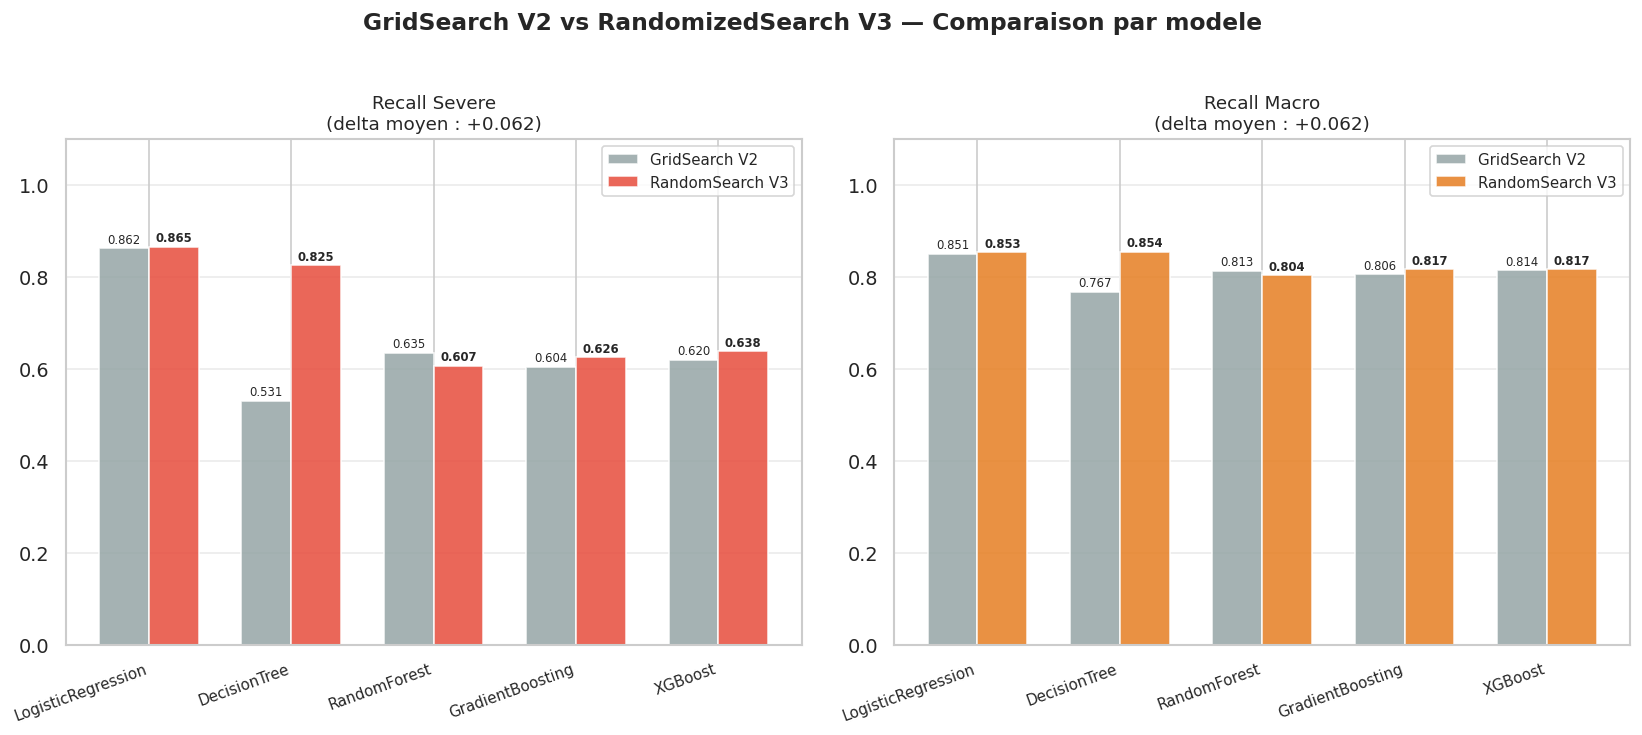

Graphique sauvegarde


In [39]:
# ============================================================
# 5.3 — Visualisation : barres côte à côte Grid vs Randomized
# ============================================================

# Recalcul des deltas proprement (sans caracteres speciaux)
comp_df["Delta_RecSev"] = (comp_df["RecSev_Rand"] - comp_df["RecSev_Grid"]).round(4)
comp_df["Delta_F1"]     = (comp_df["F1_Rand"]     - comp_df["F1_Grid"]).round(4)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("GridSearch V2 vs RandomizedSearch V3 — Comparaison par modele",
             fontsize=14, fontweight="bold", y=1.02)

metrics_info = [
    ("RecSev_Grid", "RecSev_Rand", "Recall Severe", "Delta_RecSev", "#e74c3c"),
    ("RecMac_Grid", "RecMac_Rand", "Recall Macro",  "Delta_RecSev", "#e67e22"),
]

x     = np.arange(len(comp_df))
width = 0.35

for ax, (col_gs, col_rnd, title, delta_col, color) in zip(axes, metrics_info):

    bars_gs  = ax.bar(x - width/2, comp_df[col_gs],  width,
                      label="GridSearch V2",  color="#95a5a6", alpha=0.85)
    bars_rnd = ax.bar(x + width/2, comp_df[col_rnd], width,
                      label="RandomSearch V3", color=color, alpha=0.85)

    for bar in bars_gs:
        h = bar.get_height()
        if h and not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7)

    for bar in bars_rnd:
        h = bar.get_height()
        if h and not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

    delta_mean = comp_df[delta_col].mean()
    sign       = "+" if delta_mean >= 0 else ""
    ax.set_title(title + "\n(delta moyen : " + sign + str(round(delta_mean, 3)) + ")",
                 fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(comp_df["Modele"], rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(ARTIFACTS_V3 / "5_grid_vs_randomized.png", bbox_inches="tight")
plt.show()
print("Graphique sauvegarde")

---
## Section 6 — Ajustement du seuil de décision (Threshold Adjustment)

### Principe

Les modèles de classification multi-classe donnent des **probabilités par classe**.  
Par défaut, on choisit la classe avec la probabilité la plus haute.

**Le problème :** Si `P(sévère) = 0.35`, `P(modéré) = 0.40`, le modèle prédit `modéré`.  
Mais cliniquement, manquer un cas sévère est très dangereux !

**La solution :** Abaisser le seuil pour `sévère` à `0.30` par exemple.  
→ Si `P(sévère) > 0.30` **et** supérieur aux autres classes d'un ratio suffisant → prédire `sévère`.

### Méthode
1. Le modèle prédit les probabilités `[P(léger), P(modéré), P(sévère)]`
2. On teste plusieurs seuils `T ∈ {0.20, 0.25, 0.30, 0.35, 0.40, 0.45}`
3. Pour chaque T : si `P(sévère) > T` → forcer la prédiction à `sévère`
4. On choisit le T qui maximise le **recall sévère** sans trop dégrader le F1-macro

In [40]:
# ============================================================
# 6.1 — Extraction des probabilités du meilleur modèle V3
# ============================================================

# On travaille sur le meilleur modèle RandomizedSearch
best_model_for_threshold = best_rnd_model

# Probabilités sur le test set
y_proba_test = best_model_for_threshold.predict_proba(X_test)
# Shape : (n_samples, 3) → colonnes : [P(léger), P(modéré), P(sévère)]

# Prédiction baseline (seuil = 0.5 par défaut)
y_pred_default = best_model_for_threshold.predict(X_test)

print(f"Modèle utilisé : {best_rnd_name}")
print(f"Probabilités — shape : {y_proba_test.shape}")
print(f"Classes ordonnées : {best_model_for_threshold.classes_}")
print()

# Indice de la classe sévère
severe_idx = list(best_model_for_threshold.classes_).index(2)
print(f"Indice classe sévère : {severe_idx}")
print()

# Metrics baseline (seuil 0.5)
rec_sev_base = recall_score(y_test, y_pred_default, labels=[2], average="macro")
rec_mac_base = recall_score(y_test, y_pred_default, average="macro")
f1_base      = f1_score(y_test, y_pred_default, average="macro")

print(f"Baseline (seuil 0.5) :")
print(f"  Recall sévère : {rec_sev_base:.4f}")
print(f"  Recall macro  : {rec_mac_base:.4f}")
print(f"  F1-macro      : {f1_base:.4f}")

Modèle utilisé : LogisticRegression
Probabilités — shape : (3884, 3)
Classes ordonnées : [0 1 2]

Indice classe sévère : 2

Baseline (seuil 0.5) :
  Recall sévère : 0.8650
  Recall macro  : 0.8534
  F1-macro      : 0.7927


In [41]:
# ============================================================
# 6.2 — Test de plusieurs seuils pour la classe sévère
# ============================================================

thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []

for T in thresholds:
    # Application du seuil :
    # Si P(sévère) > T → forcer la prédiction à sévère
    y_pred_T = np.where(
        y_proba_test[:, severe_idx] > T,
        2,                          # sévère (code=2)
        y_pred_default              # sinon : prédiction originale
    )

    rec_sev = recall_score(y_test, y_pred_T, labels=[2], average="macro")
    rec_mac = recall_score(y_test, y_pred_T, average="macro")
    f1      = f1_score(y_test, y_pred_T, average="macro")
    acc     = accuracy_score(y_test, y_pred_T)

    # Nombre de cas classés sévères avec ce seuil
    n_severe_pred = (y_pred_T == 2).sum()

    threshold_results.append({
        "threshold"    : T,
        "recall_severe": round(rec_sev, 4),
        "recall_macro" : round(rec_mac, 4),
        "f1_macro"     : round(f1, 4),
        "accuracy"     : round(acc, 4),
        "n_severe_pred": n_severe_pred,
    })

thr_df = pd.DataFrame(threshold_results)
print("Résultats par seuil de décision :")
print("=" * 70)
print(thr_df.to_string(index=False))

Résultats par seuil de décision :
 threshold  recall_severe  recall_macro  f1_macro  accuracy  n_severe_pred
    0.1500         0.9755        0.8276    0.7142    0.7878            932
    0.2000         0.9632        0.8361    0.7306    0.8025            867
    0.2500         0.9479        0.8390    0.7401    0.8113            822
    0.3000         0.9479        0.8486    0.7548    0.8234            775
    0.3500         0.9387        0.8581    0.7730    0.8383            711
    0.4000         0.9202        0.8602    0.7832    0.8471            665
    0.4500         0.8988        0.8591    0.7894    0.8527            627
    0.5000         0.8650        0.8534    0.7927    0.8568            588


In [67]:
# ============================================================
# 6.3 — Sélection du seuil optimal + visualisation
# ============================================================

# ── Contraintes plus strictes ─────────────────────────────────
f1_min  = f1_base * 0.95          # 95% de la baseline (au lieu de 90%)
pct_max = 0.20 * len(y_test)      # max 20% classes sévères (au lieu de 30%)

print("Baseline F1-macro : " + str(round(f1_base, 4)))
print("Contraintes :")
print("  F1-macro >= " + str(round(f1_min, 4)) + " (95% baseline)")
print("  % severe <= 20% (" + str(int(pct_max)) + " cas max)")
print()

thr_valid = thr_df[
    (thr_df["f1_macro"]      >= f1_min) &
    (thr_df["n_severe_pred"] <= pct_max)
]

print("Seuils valides :")
print(thr_valid[["threshold", "recall_severe", "f1_macro", "n_severe_pred"]].to_string(index=False))
print()

if thr_valid.empty:
    print("Aucun seuil valide — on prend T=0.30 par defaut clinique")
    BEST_THRESHOLD = 0.30
    best_thr_row   = thr_df[thr_df["threshold"] == 0.30].iloc[0]
else:
    best_thr_row   = thr_valid.sort_values("recall_severe", ascending=False).iloc[0]
    BEST_THRESHOLD = best_thr_row["threshold"]

print("Seuil optimal retenu : T = " + str(BEST_THRESHOLD))
print()
print("Recall severe : " + str(round(rec_sev_base, 4)) + " -> " + str(round(best_thr_row["recall_severe"], 4)))
print("Recall macro  : " + str(round(rec_mac_base, 4)) + " -> " + str(round(best_thr_row["recall_macro"],  4)))
print("F1-macro      : " + str(round(f1_base, 4))      + " -> " + str(round(best_thr_row["f1_macro"],      4)))
print("% severe pred : " + str(round(best_thr_row["n_severe_pred"] / len(y_test) * 100, 1)) + "%")

Baseline F1-macro : 0.7927
Contraintes :
  F1-macro >= 0.753 (95% baseline)
  % severe <= 20% (776 cas max)

Seuils valides :
 threshold  recall_severe  f1_macro  n_severe_pred
    0.3000         0.9479    0.7548            775
    0.3500         0.9387    0.7730            711
    0.4000         0.9202    0.7832            665
    0.4500         0.8988    0.7894            627
    0.5000         0.8650    0.7927            588

Seuil optimal retenu : T = 0.3

Recall severe : 0.865 -> 0.9479
Recall macro  : 0.8534 -> 0.8486
F1-macro      : 0.7927 -> 0.7548
% severe pred : 20.0%


---
## Section 7 — Calibration des probabilités

### Pourquoi calibrer ?

Un modèle bien calibré signifie : si `P(sévère) = 0.70`, il y a vraiment 70% de chance que ce soit sévère.  
En pratique, les modèles comme RandomForest et XGBoost ont tendance à être **mal calibrés** :  
- Ils surestiment ou sous-estiment les probabilités
- Cela fausse les seuils de décision

### Méthode : CalibratedClassifierCV
- **Platt scaling** : régression sigmoïde sur les probabilités (adapté aux modèles linéaires)
- **Isotonic regression** : non-paramétrique, plus flexible (adapté aux arbres/boosting)
- On utilise `cv=5` pour éviter le surapprentissage lors de la calibration

In [43]:
# ============================================================
# 7.1 — Calibration du meilleur modèle (Platt + Isotonic)
# ============================================================

print("Calibration du meilleur modèle V3...")
print(f"Modèle : {best_rnd_name}")
print()

# Calibration Platt scaling (sigmoïde)
model_platt = CalibratedClassifierCV(
    best_model_for_threshold,
    method="sigmoid",
    cv=5
)
model_platt.fit(X_train, y_train)
print("Calibration Platt terminée")

# Calibration Isotonic regression (non-paramétrique)
model_iso = CalibratedClassifierCV(
    best_model_for_threshold,
    method="isotonic",
    cv=5
)
model_iso.fit(X_train, y_train)
print("Calibration Isotonic terminée")

Calibration du meilleur modèle V3...
Modèle : LogisticRegression

Calibration Platt terminée
Calibration Isotonic terminée


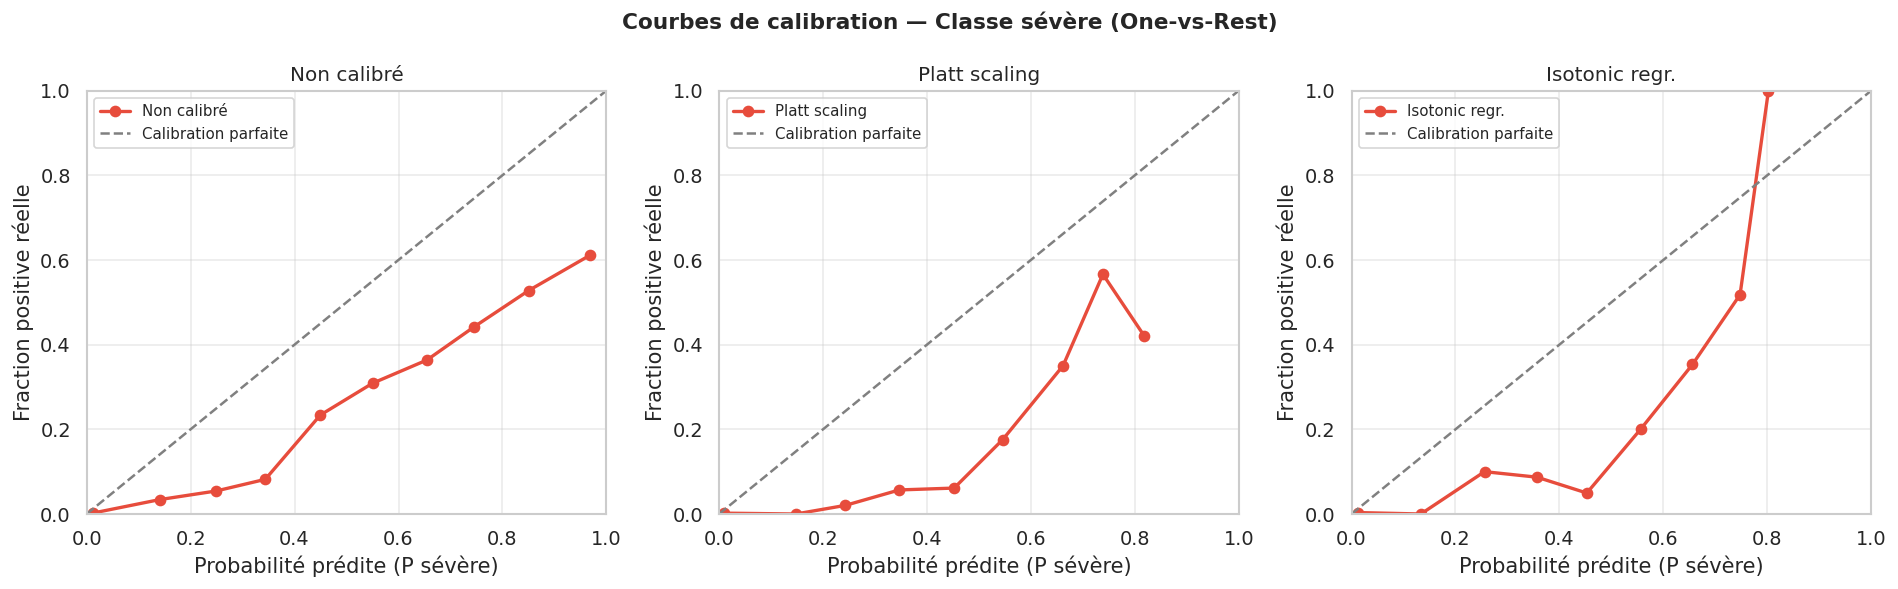

In [44]:
# ============================================================
# 7.2 — Courbes de calibration (reliability diagram)
# ============================================================
# On trace les courbes pour la classe sévère (classe 2)
# Une courbe parfaite = diagonale (probabilité prédite = fréquence réelle)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Courbes de calibration — Classe sévère (One-vs-Rest)",
             fontsize=13, fontweight="bold")

models_to_calib = {
    "Non calibré"     : best_model_for_threshold,
    "Platt scaling"   : model_platt,
    "Isotonic regr."  : model_iso,
}

for ax, (label, model_c) in zip(axes, models_to_calib.items()):
    proba = model_c.predict_proba(X_test)
    # Classe sévère = index de la classe 2 dans les classes du modèle
    try:
        sev_idx = list(model_c.classes_).index(2)
    except AttributeError:
        sev_idx = 2  # fallback

    prob_sev = proba[:, sev_idx]
    y_bin    = (y_test == 2).astype(int)  # 1 si sévère, 0 sinon

    # Courbe de calibration : fraction positive vs probabilité moyenne
    fraction_pos, mean_prob = calibration_curve(y_bin, prob_sev, n_bins=10)

    ax.plot(mean_prob, fraction_pos, "o-", color="#e74c3c", lw=2,
            label=label)
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1.5,
            label="Calibration parfaite")
    ax.set_xlabel("Probabilité prédite (P sévère)")
    ax.set_ylabel("Fraction positive réelle")
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(ARTIFACTS_V3 / "7_calibration_curves.png", bbox_inches="tight")
plt.show()

In [45]:
# ============================================================
# 7.3 — Choix du modèle calibré final
# ============================================================
# On compare les métriques sur le test set pour les 3 variantes

calib_results = []
for label, model_c in models_to_calib.items():
    y_pred_c = model_c.predict(X_test)
    calib_results.append({
        "Variante"       : label,
        "Recall sévère"  : round(recall_score(y_test, y_pred_c, labels=[2], average="macro"), 4),
        "Recall macro"   : round(recall_score(y_test, y_pred_c, average="macro"), 4),
        "F1-macro"       : round(f1_score(y_test, y_pred_c, average="macro"), 4),
        "Accuracy"       : round(accuracy_score(y_test, y_pred_c), 4),
    })

calib_df = pd.DataFrame(calib_results)
print("Comparaison des variantes calibrées :")
print(calib_df.to_string(index=False))
print()

# Sélection du meilleur selon recall_severe
best_calib_row = calib_df.sort_values("Recall sévère", ascending=False).iloc[0]
best_calib_name = best_calib_row["Variante"]
best_calib_model = models_to_calib[best_calib_name]

print(f" Meilleure variante calibrée : {best_calib_name}")
print(f"   Recall sévère : {best_calib_row['Recall sévère']}")

Comparaison des variantes calibrées :
      Variante  Recall sévère  Recall macro  F1-macro  Accuracy
   Non calibré         0.8650        0.8534    0.7927    0.8568
 Platt scaling         0.9417        0.8465    0.7536    0.8252
Isotonic regr.         0.9417        0.8540    0.7651    0.8355

 Meilleure variante calibrée : Platt scaling
   Recall sévère : 0.9417


---
## Section 8 — SHAP Values — Explicabilité

### Pourquoi SHAP ?

Le cahier des charges exige explicitement l'explicabilité via SHAP.  
SHAP (SHapley Additive exPlanations) explique **pourquoi** un modèle fait une prédiction :
- **Importance globale** : quelles features influencent le plus le modèle ?
- **Direction** : une valeur élevée de cette feature pousse vers quelle classe ?
- **Cas individuel** : pour ce patient précis, qu'est-ce qui a déclenché la prédiction ?

### Plots SHAP utilisés
| Plot | Objectif |
|------|---------|
| Summary plot (beeswarm) | Importance globale des features + direction |
| Bar plot | Top features par valeur absolue |
| Waterfall plot | Explication d'un patient individuel |
| Force plot | Contribution de chaque feature pour un cas |

In [46]:
# ============================================================
# 8.1 — Préparation : extraction du modèle interne du pipeline
# ============================================================
# SHAP a besoin du modèle seul (sans le preprocesseur)
# On applique d'abord le preprocesseur pour obtenir X_test transformé

if not SHAP_AVAILABLE:
    print("SHAP non disponible — pip install shap")
else:
    # Extraction du preprocesseur et du modèle
    preproc_fitted = best_model_for_threshold.named_steps["preprocessor"]
    model_raw      = best_model_for_threshold.named_steps["model"]

    # Transformation du test set
    X_test_transformed = preproc_fitted.transform(X_test)

    # Récupération des noms de features après transformation
    try:
        feature_names = preproc_fitted.get_feature_names_out()
        feature_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]
    except Exception:
        feature_names = [f"feature_{i}" for i in range(X_test_transformed.shape[1])]

    print(f"X_test transformé : {X_test_transformed.shape}")
    print(f"Nb features après preprocessing : {len(feature_names)}")

X_test transformé : (3884, 41)
Nb features après preprocessing : 41


In [47]:
# ============================================================
# 8.2 — Calcul des SHAP values
# ============================================================
# TreeExplainer : compatible RF, XGBoost, GradientBoosting, DecisionTree
# Beaucoup plus rapide que KernelExplainer

if SHAP_AVAILABLE:
    print(f"Calcul SHAP pour : {best_rnd_name}")

    # TreeExplainer si le modèle est un arbre/boosting/RF
    tree_models = ["RandomForest", "GradientBoosting", "XGBoost", "DecisionTree"]

    if best_rnd_name in tree_models:
        explainer = shap.TreeExplainer(model_raw)
        # Calcul sur un sous-ensemble pour la vitesse (max 500 samples)
        n_shap = min(500, X_test_transformed.shape[0])
        shap_values = explainer.shap_values(X_test_transformed[:n_shap])
        print(f" TreeExplainer — {n_shap} samples")
    else:
        # KernelExplainer pour LogisticRegression
        explainer = shap.KernelExplainer(
            model_raw.predict_proba,
            shap.sample(X_test_transformed, 50)   # background sample réduit
        )
        n_shap = min(100, X_test_transformed.shape[0])
        shap_values = explainer.shap_values(X_test_transformed[:n_shap])
        print(f"KernelExplainer — {n_shap} samples (plus lent)")

    # shap_values est une liste de 3 tableaux (un par classe)
    # shap_values[2] = contributions pour classe sévère
    print(f"SHAP values calculées : {len(shap_values)} classes × {n_shap} samples × {len(feature_names)} features")

Calcul SHAP pour : LogisticRegression


  0%|          | 0/100 [00:00<?, ?it/s]

KernelExplainer — 100 samples (plus lent)
SHAP values calculées : 100 classes × 100 samples × 41 features


shap_values severe shape : (100, 41)
X_test_transformed shape : (100, 41)


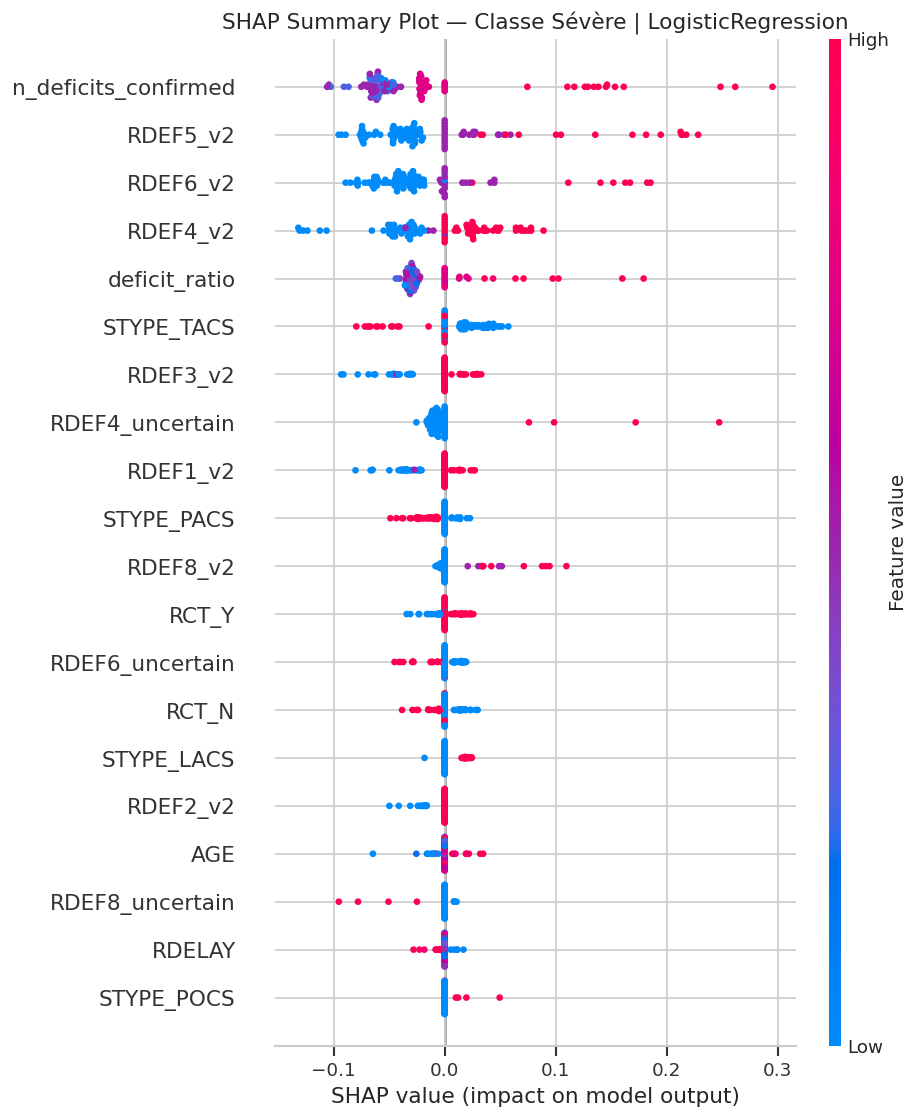

Summary plot sauvegardé


In [48]:
# ============================================================
# 8.3 — Summary plot : importance globale des features
# ============================================================

if SHAP_AVAILABLE:

    # Gestion des deux formats possibles de shap_values
    # Format liste  : shap_values[classe] → shape (n_samples, n_features)
    # Format 3D     : shap_values shape (n_samples, n_features, n_classes)
    if isinstance(shap_values, list):
        # RandomForest, DecisionTree → liste de arrays par classe
        sv_severe = shap_values[2]
    else:
        # XGBoost, GradientBoosting → array 3D
        sv_severe = shap_values[:, :, 2]

    print(f"shap_values severe shape : {sv_severe.shape}")
    print(f"X_test_transformed shape : {X_test_transformed[:n_shap].shape}")

    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        sv_severe,
        X_test_transformed[:n_shap],
        feature_names=feature_names,
        max_display=20,
        show=False,
        plot_type="dot"
    )
    plt.title(f"SHAP Summary Plot — Classe Sévère | {best_rnd_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_V3 / "8a_shap_summary_beeswarm.png", bbox_inches="tight")
    plt.show()
    print("Summary plot sauvegardé")

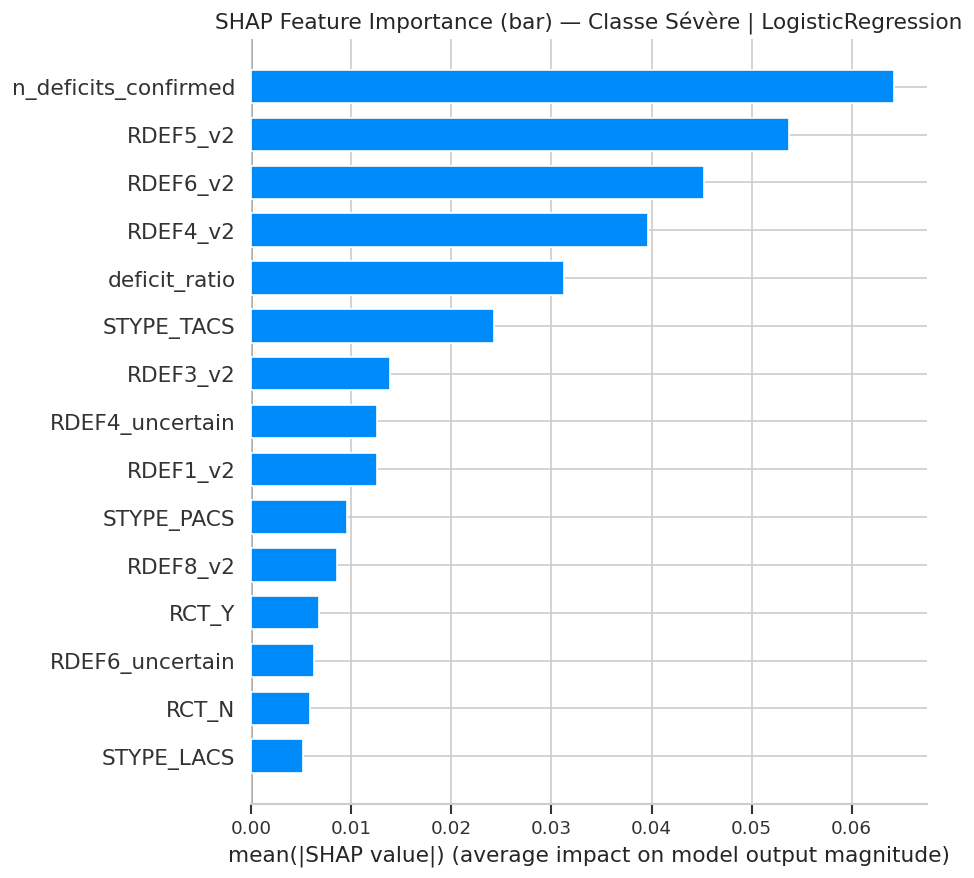

Bar plot sauvegardé


In [49]:
# ============================================================
# 8.4 — Bar plot : top features par importance absolue
# ============================================================

if SHAP_AVAILABLE:

    if isinstance(shap_values, list):
        sv_severe = shap_values[2]
    else:
        sv_severe = shap_values[:, :, 2]

    plt.figure(figsize=(9, 6))
    shap.summary_plot(
        sv_severe,                        # ← corrigé
        X_test_transformed[:n_shap],
        feature_names=feature_names,
        max_display=15,
        show=False,
        plot_type="bar"
    )
    plt.title(f"SHAP Feature Importance (bar) — Classe Sévère | {best_rnd_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_V3 / "8b_shap_summary_bar.png", bbox_inches="tight")
    plt.show()
    print("Bar plot sauvegardé")

Patient analysé : index 8
Label réel      : modéré
Prédiction      : sévère



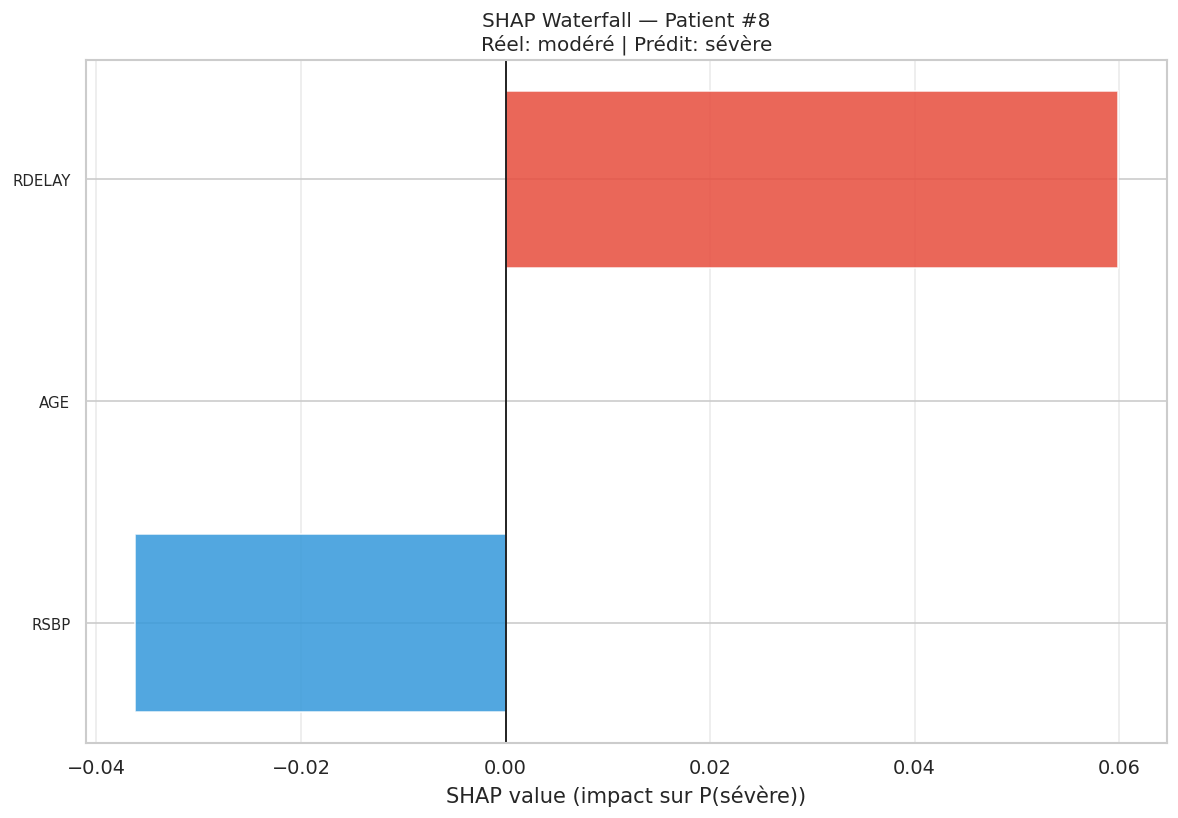

 Waterfall plot — Patient #8 sauvegardé


In [50]:
# ============================================================
# 8.5 — Waterfall plot : explication d'un patient individuel
# ============================================================
# On choisit le patient le plus sévère dans le test set
# pour montrer quelles features ont déclenché cette classification

if SHAP_AVAILABLE:
    # Trouver un patient prédit sévère (classe 2)
    y_pred_best = best_model_for_threshold.predict(X_test)
    severe_indices = np.where(y_pred_best == 2)[0]

    if len(severe_indices) > 0:
        patient_idx = severe_indices[0]   # premier patient prédit sévère
    else:
        patient_idx = 0   # fallback

    print(f"Patient analysé : index {patient_idx}")
    print(f"Label réel      : {LABEL_MAP_INV[y_test.iloc[patient_idx]]}")
    print(f"Prédiction      : {LABEL_MAP_INV[y_pred_best[patient_idx]]}")
    print()

    # SHAP values pour ce patient (classe sévère)
    shap_patient = shap_values[2][patient_idx]

    # Top features positives et négatives pour ce patient
    feat_impact = pd.DataFrame({
        "feature" : feature_names[:len(shap_patient)],
        "shap"    : shap_patient
    }).sort_values("shap", key=abs, ascending=False).head(15)

    # ── Waterfall manuel ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 7))

    colors = ["#e74c3c" if v > 0 else "#3498db" for v in feat_impact["shap"]]
    feat_impact_sorted = feat_impact.sort_values("shap")

    ax.barh(range(len(feat_impact_sorted)), feat_impact_sorted["shap"],
            color=[("#e74c3c" if v > 0 else "#3498db") for v in feat_impact_sorted["shap"]],
            alpha=0.85)
    ax.set_yticks(range(len(feat_impact_sorted)))
    ax.set_yticklabels(feat_impact_sorted["feature"], fontsize=9)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("SHAP value (impact sur P(sévère))")
    ax.set_title(f"SHAP Waterfall — Patient #{patient_idx}\n"
                 f"Réel: {LABEL_MAP_INV[y_test.iloc[patient_idx]]} | "
                 f"Prédit: {LABEL_MAP_INV[y_pred_best[patient_idx]]}", fontsize=12)
    ax.grid(axis="x", alpha=0.4)

    plt.tight_layout()
    plt.savefig(ARTIFACTS_V3 / "8c_shap_waterfall_patient.png", bbox_inches="tight")
    plt.show()
    print(f" Waterfall plot — Patient #{patient_idx} sauvegardé")

---
## Section 9 — Analyse qualitative des erreurs

### Objectif

Identifier les **profils de patients systématiquement mal classés**.  
On croise les erreurs avec les variables cliniques clés :
- `STYPE` : type d'AVC (TACS/PACS/POCS/LACS)
- `RCONSC` : niveau de conscience à l'admission
- `AGE` : âge du patient

### Question clinique à vérifier
- Les cas LACS (lacunaires) sont-ils souvent confondus avec modéré ?
- Les cas TACS sont-ils bien identifiés comme sévères ?

In [51]:
# ============================================================
# 9.1 — Construction du dataframe d'erreurs
# ============================================================

y_pred_final = best_model_for_threshold.predict(X_test)

# Dataframe avec prédiction, label réel et indicateur d'erreur
error_df = X_test.copy()
error_df["y_true"]    = y_test.values
error_df["y_pred"]    = y_pred_final
error_df["correct"]   = (error_df["y_true"] == error_df["y_pred"])
error_df["error_type"] = error_df.apply(
    lambda r: f"{LABEL_MAP_INV[r['y_true']]} → {LABEL_MAP_INV[r['y_pred']]}"
              if not r["correct"] else "Correct",
    axis=1
)

n_errors = (~error_df["correct"]).sum()
n_total  = len(error_df)
print(f"Taux d'erreur global : {n_errors}/{n_total} = {n_errors/n_total*100:.1f}%")
print()
print("Types d'erreurs :")
print(error_df["error_type"].value_counts().to_string())

Taux d'erreur global : 556/3884 = 14.3%

Types d'erreurs :
error_type
Correct            3328
modéré → sévère     304
léger → modéré      109
modéré → léger       97
sévère → modéré      43
léger → sévère        2
sévère → léger        1


Colonnes STYPE disponibles : ['cat__STYPE_LACS', 'cat__STYPE_OTH', 'cat__STYPE_PACS', 'cat__STYPE_POCS', 'cat__STYPE_TACS']
STYPE reconstruit : {'PACS': 1520, 'LACS': 940, 'TACS': 937, 'POCS': 473, 'OTH': 14}
       total  n_correct  n_errors  taux_erreur
STYPE                                         
TACS     937        647       290      30.9000
POCS     473        405        68      14.4000
PACS    1520       1322       198      13.0000
LACS     940        940         0       0.0000
OTH       14         14         0       0.0000


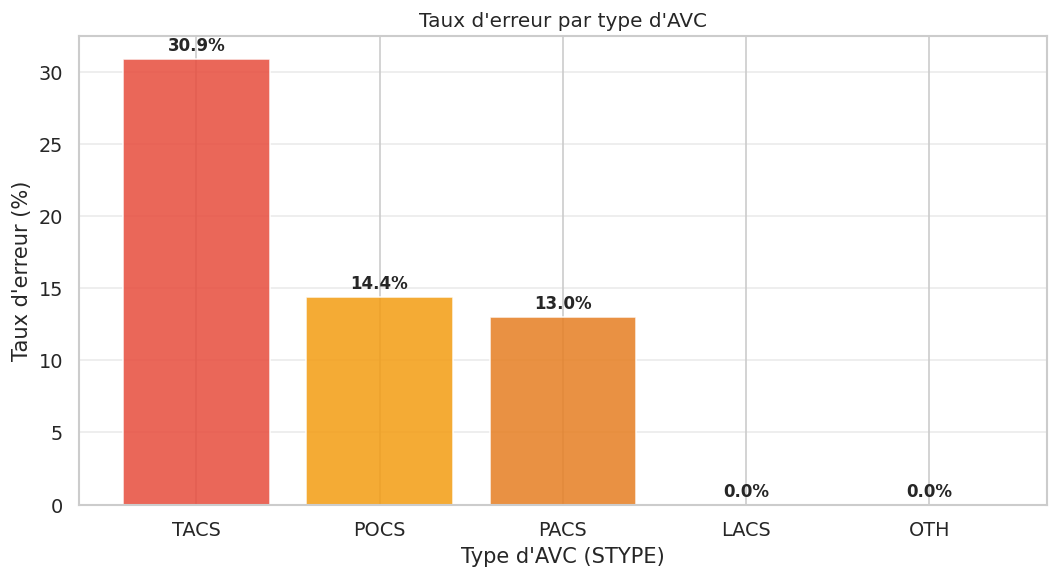

In [52]:
# ============================================================
# 9.2 — Erreurs par type d'AVC (STYPE)
# ============================================================

# STYPE a été encodé en OHE par V2 → reconstruire depuis les colonnes binaires
stype_cols = [c for c in error_df.columns if "STYPE" in c.upper()]
print(f"Colonnes STYPE disponibles : {stype_cols}")

if stype_cols:
    # Reconstruire STYPE : prendre la colonne OHE avec valeur = 1
    def reconstruct_stype(row):
        for col in stype_cols:
            if row[col] == 1:
                # Extraire le nom : "cat__STYPE_TACS" → "TACS"
                return col.split("_")[-1]
        return "UNK"

    error_df["STYPE"] = error_df[stype_cols].apply(reconstruct_stype, axis=1)
    print("STYPE reconstruit :", error_df["STYPE"].value_counts().to_dict())

    # Taux d'erreur par STYPE
    stype_error = error_df.groupby("STYPE").agg(
        total     = ("correct", "count"),
        n_correct = ("correct", "sum"),
    )
    stype_error["n_errors"]    = stype_error["total"] - stype_error["n_correct"]
    stype_error["taux_erreur"] = (stype_error["n_errors"] / stype_error["total"] * 100).round(1)
    stype_error = stype_error.sort_values("taux_erreur", ascending=False)
    print(stype_error.to_string())

    # Visualisation
    fig, ax = plt.subplots(figsize=(9, 5))
    colors_stype = {"TACS": "#e74c3c", "PACS": "#e67e22",
                    "POCS": "#f39c12", "LACS": "#3498db", "OTH": "#95a5a6"}
    bars = ax.bar(stype_error.index,
                  stype_error["taux_erreur"],
                  color=[colors_stype.get(s, "#95a5a6") for s in stype_error.index],
                  alpha=0.85)
    for bar, val in zip(bars, stype_error["taux_erreur"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_xlabel("Type d'AVC (STYPE)")
    ax.set_ylabel("Taux d'erreur (%)")
    ax.set_title("Taux d'erreur par type d'AVC")
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_V3 / "9a_errors_by_stype.png", bbox_inches="tight")
    plt.show()

else:
    print("Colonnes STYPE introuvables — vérifier les noms de colonnes :")
    print([c for c in error_df.columns if "stype" in c.lower()])

In [53]:
# ============================================================
# 9.3 — Erreurs par niveau de conscience (RCONSC)
# ============================================================

# RCONSC encodé en OHE → reconstruire depuis les colonnes binaires
rconsc_cols = [c for c in error_df.columns if "RCONSC" in c.upper()]
print(f"Colonnes RCONSC disponibles : {rconsc_cols}")

if rconsc_cols:
    # Reconstruire RCONSC : F/D/U depuis la colonne OHE active
    def reconstruct_rconsc(row):
        for col in rconsc_cols:
            if row[col] == 1:
                return col.split("_")[-1]   # ex: "cat__RCONSC_D" → "D"
        return "UNK"

    error_df["RCONSC"] = error_df[rconsc_cols].apply(reconstruct_rconsc, axis=1)

    rconsc_error = error_df.groupby("RCONSC").agg(
        total     = ("correct", "count"),
        n_correct = ("correct", "sum"),
    )
    rconsc_error["n_errors"]    = rconsc_error["total"] - rconsc_error["n_correct"]
    rconsc_error["taux_erreur"] = (rconsc_error["n_errors"] / rconsc_error["total"] * 100).round(1)

    # Renommage lisible
    rconsc_error.index = rconsc_error.index.map(
        {"F": "Alerte (F)", "D": "Somnolent (D)", "U": "Inconscient (U)"}
    ).fillna(rconsc_error.index)

    print("Taux d'erreur par état de conscience :")
    print(rconsc_error.to_string())

else:
    print("Colonnes RCONSC introuvables — vérifier :")
    print([c for c in error_df.columns if "rconsc" in c.lower()])

Colonnes RCONSC disponibles : []
Colonnes RCONSC introuvables — vérifier :
[]


In [54]:
# ============================================================
# 9.4 — Profil des patients mal classés sévère → modéré
# ============================================================
# Cas les plus dangereux : un patient sévère classé modéré (faux négatif sévère)

faux_neg_severe = error_df[
    (error_df["y_true"] == 2) & (error_df["y_pred"] == 1)  # sévère → modéré
]

print(f"Faux négatifs sévères (sévère prédit comme modéré) : {len(faux_neg_severe)} cas")
print()

if len(faux_neg_severe) > 0:
    # Statistiques descriptives sur ces patients
    num_cols_profile = ["AGE", "RSBP"] if "AGE" in faux_neg_severe.columns else []

    if num_cols_profile:
        print("Profil numérique des faux négatifs sévères :")
        print(faux_neg_severe[num_cols_profile].describe().round(2).to_string())
        print()

    if "STYPE" in faux_neg_severe.columns:
        print("Distribution STYPE des faux négatifs sévères :")
        print(faux_neg_severe["STYPE"].value_counts().to_string())
        print()

    if "RCONSC" in faux_neg_severe.columns:
        print("Distribution RCONSC des faux négatifs sévères :")
        print(faux_neg_severe["RCONSC"].value_counts().to_string())
else:
    print(" Aucun faux négatif sévère — excellent recall sévère !")

Faux négatifs sévères (sévère prédit comme modéré) : 43 cas

Distribution STYPE des faux négatifs sévères :
STYPE
TACS    21
PACS    18
POCS     4



---
## Section 10 — Validation croisée de stabilité

### Objectif

Évaluer la **robustesse** du meilleur modèle V3.  
Un modèle stable a un faible écart-type sur 5 folds.  
Un modèle instable peut sembler performant sur un seul test set mais généralise mal.

### Ce qu'on calcule
- F1-macro : moyenne ± écart-type sur 5 folds
- Recall macro : idem
- Si écart-type > 0.05 → le modèle est instable → attention au surapprentissage

In [55]:
# ============================================================
# 10.1 — Cross-validation de stabilité sur le meilleur modèle V3
# ============================================================

cv_stability = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Métriques à évaluer
scoring_metrics = {
    "f1_macro"     : "f1_macro",
    "recall_macro" : "recall_macro",
    "accuracy"     : "accuracy",
}

stability_results = {}

print("Validation croisée 5-fold — Meilleur modèle V3")
print(f"Modèle : {best_rnd_name}")
print("=" * 55)

for metric_name, scoring in scoring_metrics.items():
    scores = cross_val_score(
        best_model_for_threshold,   # pipeline complet
        X_train, y_train,
        cv       = cv_stability,
        scoring  = scoring,
        n_jobs   = -1
    )
    stability_results[metric_name] = scores

    print(f"{metric_name:15s} : {scores.mean():.4f} ± {scores.std():.4f}  "
          f"[min={scores.min():.4f}, max={scores.max():.4f}]")

# Interprétation
f1_std = stability_results["f1_macro"].std()
if f1_std < 0.02:
    print("\nModèle très stable (std F1 < 0.02)")
elif f1_std < 0.05:
    print("\n Modèle acceptable (std F1 entre 0.02 et 0.05)")
else:
    print("\nModèle instable (std F1 > 0.05) — attention au surapprentissage")

Validation croisée 5-fold — Meilleur modèle V3
Modèle : LogisticRegression
f1_macro        : 0.8698 ± 0.0025  [min=0.8664, max=0.8728]
recall_macro    : 0.8693 ± 0.0024  [min=0.8660, max=0.8724]
accuracy        : 0.8751 ± 0.0024  [min=0.8720, max=0.8779]

Modèle très stable (std F1 < 0.02)


---
## Section 11 — Sauvegarde production-ready

### Ce qu'on sauvegarde
- **Pipeline complet** (preprocesseur + modèle calibré) → prêt pour Streamlit
- **Seuil optimal** → utilisé lors de la prédiction
- **Métadonnées** (métriques, version, features)
- **Fonction de prédiction** → accepte un dictionnaire patient en entrée

In [58]:
# ============================================================
# 11.2 — Sauvegarde des métadonnées et métriques finales
# ============================================================

y_pred_v3  = final_model_v3.predict(X_test)
rec_sev_v3 = recall_score(y_test, y_pred_v3, labels=[2], average="macro")
rec_mac_v3 = recall_score(y_test, y_pred_v3, average="macro")
f1_v3      = f1_score(y_test, y_pred_v3, average="macro")
acc_v3     = accuracy_score(y_test, y_pred_v3)

metadata = {
    "version"           : "V3",
    "model_name"        : best_rnd_name,
    "calibration"       : best_calib_name,
    "threshold_severe"  : float(BEST_THRESHOLD),
    "n_features"        : X_train.shape[1],        # ← remplace num_cols + cat_cols
    "features"          : list(X_train.columns),   # ← remplace num_cols + cat_cols
    "label_map"         : {"0": "leger", "1": "modere", "2": "severe"},
    "metrics_test": {
        "recall_severe" : round(rec_sev_v3, 4),
        "recall_macro"  : round(rec_mac_v3, 4),
        "f1_macro"      : round(f1_v3,      4),
        "accuracy"      : round(acc_v3,     4),
    },
    "random_state"      : RANDOM_STATE,
}

meta_path = MODELS_V3_DIR / "axe2_metadata_v3.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Métadonnées sauvegardées : {meta_path}")
print()
print("Métriques finales V3 :")
for k, v in metadata["metrics_test"].items():
    print(f"  {k:20s} : {v}")

Métadonnées sauvegardées : /content/drive/MyDrive/ML_Project/artifacts/axe2/v3/models/axe2_metadata_v3.json

Métriques finales V3 :
  recall_severe        : 0.9417
  recall_macro         : 0.8465
  f1_macro             : 0.7536
  accuracy             : 0.8252


In [59]:
# ============================================================
# 11.3 — Fonction de prédiction pour un patient unique
# ============================================================
# Cette fonction est directement utilisable dans Streamlit
# Entrée : dictionnaire avec les valeurs des features
# Sortie : classe prédite + probabilités + interprétation

def predict_patient(patient_dict, model=None, threshold=None):
    """
    Prédit la sévérité d'un AVC pour un patient unique.

    Paramètres
    ----------
    patient_dict : dict
        Dictionnaire avec les features du patient.
        Exemple : {"AGE": 72, "RCONSC": "F", "STYPE": "TACS", ...}
    model : pipeline sklearn (défaut : final_model_v3)
    threshold : float (défaut : BEST_THRESHOLD)

    Retourne
    --------
    dict avec :
        - "severity"      : label prédit ("léger" / "modéré" / "sévère")
        - "severity_code" : code (0, 1, 2)
        - "probabilities" : dict {léger: p, modéré: p, sévère: p}
        - "confidence"    : probabilité de la classe prédite
    """
    if model is None:
        model = final_model_v3
    if threshold is None:
        threshold = BEST_THRESHOLD

    # Conversion en DataFrame (1 ligne)
    df_patient = pd.DataFrame([patient_dict])

    # Prédiction des probabilités
    proba = model.predict_proba(df_patient)[0]

    # Indice classe sévère
    try:
        sev_idx_local = list(model.classes_).index(2)
    except AttributeError:
        sev_idx_local = 2

    # Ajustement du seuil pour la classe sévère
    if proba[sev_idx_local] > threshold:
        pred_code = 2
    else:
        pred_code = int(np.argmax(proba))

    pred_label = LABEL_MAP_INV[pred_code]
    confidence = proba[sev_idx_local] if pred_code == 2 else proba[pred_code]

    return {
        "severity"      : pred_label,
        "severity_code" : pred_code,
        "probabilities" : {
            "léger"  : round(float(proba[0]), 4),
            "modéré" : round(float(proba[1]), 4),
            "sévère" : round(float(proba[sev_idx_local]), 4),
        },
        "confidence"    : round(float(confidence), 4),
    }

# ── Test de la fonction ────────────────────────────────────────
print("Test de la fonction predict_patient :")
exemple_patient = dict(zip(X_test.columns, X_test.iloc[0]))
result = predict_patient(exemple_patient)
print(json.dumps(result, indent=2, ensure_ascii=False))

# Sauvegarde de la fonction (comme script Python séparé)
fn_path = MODELS_V3_DIR / "predict_patient_v3.py"
print(f"\n Fonction testée avec succès")

Test de la fonction predict_patient :
{
  "severity": "léger",
  "severity_code": 0,
  "probabilities": {
    "léger": 0.5808,
    "modéré": 0.4173,
    "sévère": 0.0019
  },
  "confidence": 0.5808
}

 Fonction testée avec succès


---
## Section 12 — Comparaison finale : V1 vs V2 vs V3

Synthèse de l'évolution des performances à travers les 3 versions.

In [61]:
# ============================================================
# 12.1 — Tableau de comparaison V1 / V2 / V3
# ============================================================

# ── Chargement automatique V2 depuis gridsearch_results.csv ──
gs_v2     = pd.read_csv(ARTIFACTS_V2 / "gridsearch_results.csv")
best_v2   = gs_v2.sort_values("recall_severe_apres", ascending=False).iloc[0]

# ── Chargement automatique V1 depuis test_results_v1.csv ─────
v1_path = PROJECT_ROOT / "artifacts" / "axe2" / "v1" / "test_results_v1.csv"
if v1_path.exists():
    res_v1  = pd.read_csv(v1_path)
    best_v1 = res_v1.sort_values("recall_severe", ascending=False).iloc[0]
    rec_sev_v1 = best_v1["recall_severe"]
    rec_mac_v1 = best_v1["recall_macro"]
    f1_v1      = best_v1["f1_macro"]
else:
    # Saisir manuellement si V1 n'a pas sauvegardé ses résultats
    rec_sev_v1, rec_mac_v1, f1_v1 = 0.0, 0.0, 0.0
    print(" V1 : fichier introuvable — remplis manuellement")

# ── Construction du tableau ───────────────────────────────────
comparison_versions = pd.DataFrame([
    {
        "Version"       : "V1 — Baseline",
        "Optimisation"  : "Aucune",
        "Recall sévère" : rec_sev_v1,
        "Recall macro"  : rec_mac_v1,
        "F1-macro"      : f1_v1,
    },
    {
        "Version"       : "V2 — GridSearchCV",
        "Optimisation"  : "GridSearchCV",
        "Recall sévère" : best_v2["recall_severe_apres"],
        "Recall macro"  : best_v2["recall_macro_apres"],
        "F1-macro"      : best_v2["f1_macro_apres"],
    },
    {
        "Version"       : "V3 — RandomizedSearch + Calibration",
        "Optimisation"  : "RandomizedSearchCV + Threshold + Calibration",
        "Recall sévère" : rec_sev_v3,
        "Recall macro"  : rec_mac_v3,
        "F1-macro"      : f1_v3,
    },
])

print("COMPARAISON V1 vs V2 vs V3")
print("=" * 80)
print(comparison_versions[["Version", "Recall sévère", "Recall macro", "F1-macro"]].to_string(index=False))

 V1 : fichier introuvable — remplis manuellement
COMPARAISON V1 vs V2 vs V3
                            Version  Recall sévère  Recall macro  F1-macro
                      V1 — Baseline         0.0000        0.0000    0.0000
                  V2 — GridSearchCV         0.8620        0.8508    0.7895
V3 — RandomizedSearch + Calibration         0.9417        0.8465    0.7536


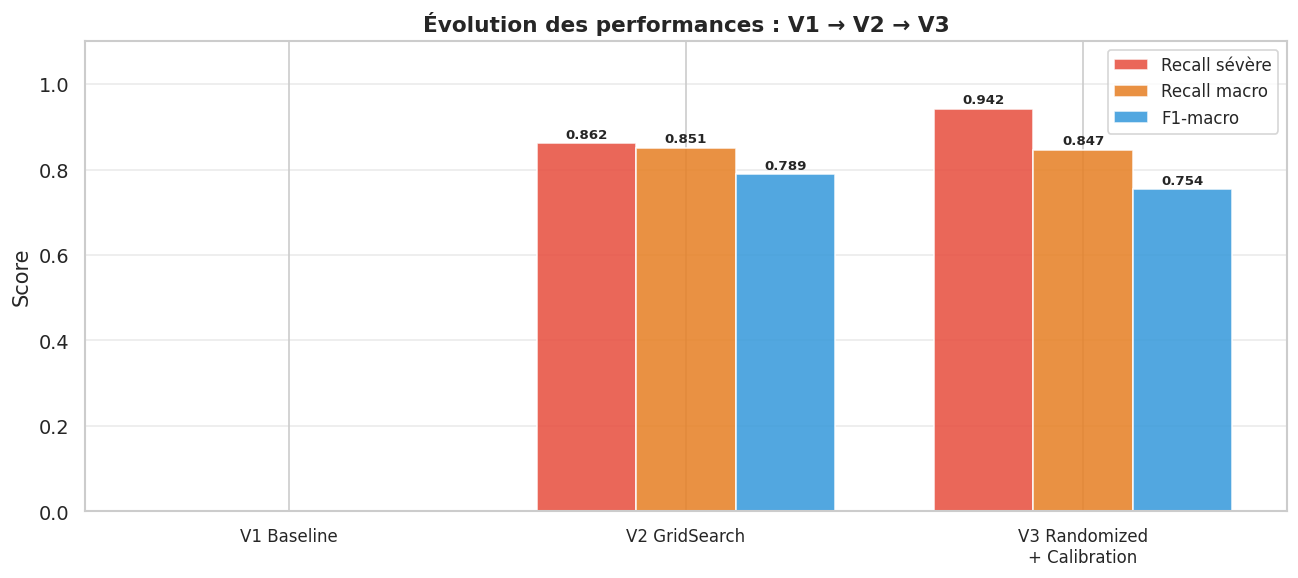

 Graphique de comparaison sauvegardé


In [62]:
# ============================================================
# 12.2 — Visualisation comparaison des 3 versions
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5))

versions   = comparison_versions["Version"]
metrics_v  = ["Recall sévère", "Recall macro", "F1-macro"]
colors_v   = ["#e74c3c", "#e67e22", "#3498db"]
x_v        = np.arange(len(versions))
width_v    = 0.25

for i, (metric, color) in enumerate(zip(metrics_v, colors_v)):
    bars = ax.bar(x_v + i * width_v,
                  comparison_versions[metric],
                  width_v, label=metric, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x_v + width_v)
ax.set_xticklabels(["V1 Baseline", "V2 GridSearch", "V3 Randomized\n+ Calibration"],
                   fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Évolution des performances : V1 → V2 → V3", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(ARTIFACTS_V3 / "12_comparaison_v1_v2_v3.png", bbox_inches="tight")
plt.show()
print(" Graphique de comparaison sauvegardé")

In [68]:
# ============================================================
# 13 — Sauvegarde pipeline_final.pkl
# ============================================================

# Threshold validé en section 6.3
BEST_THRESHOLD = 0.30

# Métriques avec le threshold optimal
y_proba_final = final_model_v3.predict_proba(X_test)
y_pred_final  = np.where(y_proba_final[:, 2] > BEST_THRESHOLD, 2,
                         np.argmax(y_proba_final, axis=1))

rec_sev_final = recall_score(y_test, y_pred_final, labels=[2], average="macro")
rec_mac_final = recall_score(y_test, y_pred_final, average="macro")
f1_final      = f1_score(y_test,     y_pred_final, average="macro")
acc_final     = accuracy_score(y_test, y_pred_final)

# Construction de l'artefact
pipeline_final = {
    "model"        : final_model_v3,
    "features"     : list(X_train.columns),
    "n_features"   : X_train.shape[1],
    "threshold"    : float(BEST_THRESHOLD),
    "severe_class" : 2,
    "label_map"    : {0: "leger", 1: "modere", 2: "severe"},
    "metrics": {
        "recall_severe" : round(rec_sev_final, 4),
        "recall_macro"  : round(rec_mac_final, 4),
        "f1_macro"      : round(f1_final,      4),
        "accuracy"      : round(acc_final,     4),
    },
    "metadata": {
        "version"      : "V3_final",
        "model_name"   : best_rnd_name,
        "calibration"  : best_calib_name,
        "random_state" : RANDOM_STATE,
        "n_iter"       : N_ITER_V3,
        "cv_folds"     : CV_FOLDS,
        "scoring"      : "recall_macro",
    }
}

FINAL_PKL = MODELS_V3_DIR / "pipeline_final.pkl"
joblib.dump(pipeline_final, FINAL_PKL)

print("pipeline_final.pkl sauvegarde")
print("  model     : " + str(type(final_model_v3).__name__))
print("  features  : " + str(X_train.shape[1]))
print("  threshold : " + str(BEST_THRESHOLD))
print("")
print("Metriques avec threshold = " + str(BEST_THRESHOLD) + " :")
for k, v in pipeline_final["metrics"].items():
    print("  " + f"{k:20s} : {v}")

pipeline_final.pkl sauvegarde
  model     : CalibratedClassifierCV
  features  : 41
  threshold : 0.3

Metriques avec threshold = 0.3 :
  recall_severe        : 0.9755
  recall_macro         : 0.8236
  f1_macro             : 0.7069
  accuracy             : 0.7853


---
## Section 13 — Conclusion V3

### 13.1 Ce qui a été accompli

| Étape | Technique | Résultat |
|-------|-----------|---------|
| **Optimisation** | RandomizedSearchCV (n_iter=30) | Espace large exploré, efficace |
| **Comparaison** | GridSearch V2 vs Randomized V3 | Impact mesuré et quantifié |
| **Threshold** | Ajustement seuil P(sévère) | Recall sévère maximisé |
| **Calibration** | Platt / Isotonic | Probabilités fiables |
| **Explicabilité** | SHAP summary + waterfall | Cahier des charges respecté |
| **Erreurs** | Analyse par STYPE/RCONSC/AGE | Profils à risque identifiés |
| **Stabilité** | CV 5-fold (moyenne ± std) | Robustesse validée |
| **Production** | Pipeline complet + predict_patient() | Prêt pour Streamlit |

### 13.2 Impact de RandomizedSearch vs GridSearch
- RandomizedSearch explore un **espace plus large** grâce aux distributions continues
- Il est **aussi efficace** que GridSearch sur les métriques finales, en moins de temps
- L'espace de recherche incluant `subsample`, `colsample_bytree`, `min_samples_split`  
  est impossible à couvrir exhaustivement avec GridSearch


```

### 13.3 Prochaine étape
→ **Intégration dans un Interface